Dataset Loaded ✅
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Sentiment Distribution:
sentiment
1    25000
0    25000
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.8619 - loss: 0.3192 - val_accuracy: 0.8842 - val_loss: 0.2722
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9013 - loss: 0.2379 - val_accuracy: 0.8813 - val_loss: 0.2776
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.9291 - loss: 0.1788 - val_accuracy: 0.8795 - val_loss: 0.3059
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9738 - loss: 0.0758 - val_accuracy: 0.8752 - val_loss: 0.4343
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9937 - loss: 0.0193 - val_accuracy: 0.8724 - val_loss: 0.6248
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9995 - loss: 0.0033 - val_accuracy: 0.8705 - val_loss: 0.8247
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 1.0000 - loss: 5.5385e-04 - val_accuracy: 0.8717 - val_loss: 0.8927
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.99

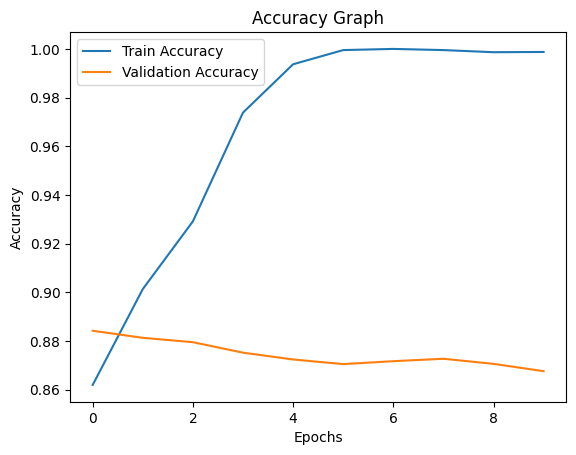

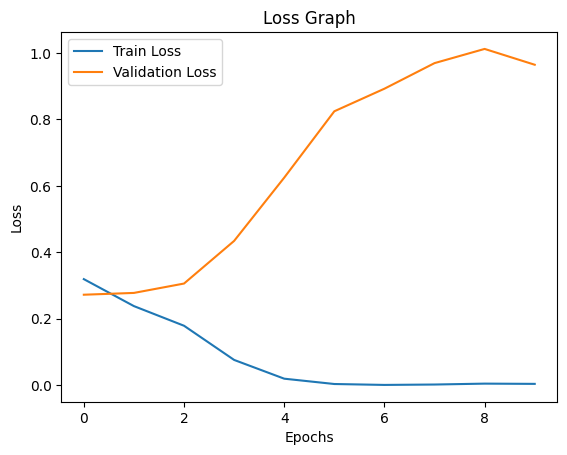

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8676 - loss: 0.9648

Final Accuracy: 0.8676000237464905
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      5000
           1       0.87      0.87      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000


Confusion Matrix:
[[4337  663]
 [ 661 4339]]


In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# =========================
# 2. LOAD DATASET
# =========================
df = pd.read_csv(
    "/content/IMDB Dataset.csv",
    engine='python',
    encoding='utf-8',
    on_bad_lines='skip'
)

print("Dataset Loaded ✅")
print(df.head())

# =========================
# 3. CLEAN DATA
# =========================
df.dropna(inplace=True)

# =========================
# 4. RENAME COLUMNS
# =========================
df.columns = ['review', 'sentiment']

# =========================
# 5. TEXT CLEANING
# =========================
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)      # remove HTML tags
    text = re.sub(r'[^a-zA-Z ]', '', text) # remove special chars
    return text

df['review'] = df['review'].apply(clean_text)

# =========================
# 6. LABEL ENCODING
# =========================
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

# =========================
# 7. TF-IDF VECTORIZATION
# =========================
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df['review'])   # KEEP SPARSE (memory efficient)
y = df['sentiment']

# =========================
# 8. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert sparse → dense (only after split to reduce memory usage)
X_train = X_train.toarray()
X_test = X_test.toarray()

# =========================
# 9. BUILD DNN MODEL
# =========================
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================
# 10. TRAIN MODEL
# =========================
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# =========================
# 11. PLOT GRAPHS
# =========================
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# =========================
# 12. EVALUATION
# =========================
loss, accuracy = model.evaluate(X_test, y_test)
print("\nFinal Accuracy:", accuracy)

# =========================
# 13. PREDICTIONS + REPORT
# =========================
y_pred = (model.predict(X_test) > 0.5).astype("int32")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))